# Go2 EEG 原始数据预处理后再切分演示

本 Notebook 演示另一种更标准的 EEG 预处理思路：先读取每个 session 的原始 EDF 数据，在连续信号上完成滤波、重参考、坏通道/坏段检查、ICA 等步骤，然后再根据 `go2_keyboard_events_*.csv` 中的时间戳切分出监督学习数据。

## 1. 导入数据

In [13]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
from scipy import signal
from sklearn.preprocessing import LabelEncoder

try:
    import mne
except ImportError as exc:
    raise ImportError(
        "本 Notebook 需要 mne。请先在当前 Python 环境中安装：pip install mne"
    ) from exc

plt.style.use("seaborn-v0_8-whitegrid")

available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font_name in ["Microsoft YaHei", "SimHei", "SimSun", "Noto Sans CJK SC", "Source Han Sans SC"]:
    if font_name in available_fonts:
        plt.rcParams["font.sans-serif"] = [font_name, "DejaVu Sans"]
        break
else:
    print("未找到常见中文字体；如果图中中文显示为方块，请安装 Microsoft YaHei、SimHei 或 Noto Sans CJK SC。")
plt.rcParams["axes.unicode_minus"] = False

mne.set_log_level("WARNING")
warnings.filterwarnings("ignore", category=RuntimeWarning)


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "raw").exists():
            return candidate
    raise FileNotFoundError("无法从当前目录向上找到 data/raw。")


PROJECT_ROOT = find_project_root(Path.cwd())
RAW_ROOT = PROJECT_ROOT / "data" / "raw"
OUTPUT_PATH = PROJECT_ROOT / "data" / "go2_eeg_dataset_preprocessed_from_raw.npz"

# print(f"项目目录: {PROJECT_ROOT}")
# print(f"原始数据目录: {RAW_ROOT}")


## 2. 查找 session、EDF 文件和事件日志

每个 session 应该包含一个 NeuroAI 导出的 `data.edf`，以及一个 Go2 键盘实验事件日志 `go2_keyboard_events_*.csv`。

In [14]:
def find_sessions(raw_root: Path) -> list[dict]:
    sessions = []
    for session_dir in sorted(raw_root.glob("go2_keyboard_*")):
        if not session_dir.is_dir():
            continue
        edf_files = sorted(session_dir.glob("**/data.edf"))
        event_files = sorted(session_dir.glob("go2_keyboard_events_*.csv"))
        if edf_files and event_files:
            sessions.append(
                {
                    "session_dir": session_dir,
                    "edf_path": edf_files[0],
                    "event_path": event_files[0],
                }
            )
    return sessions


sessions = find_sessions(RAW_ROOT)
print(f"找到 {len(sessions)} 个 session")
for i, item in enumerate(sessions, 1):
    print()
    print(f"Session {i}")
    print(f"- EDF: {item['edf_path'].relative_to(PROJECT_ROOT)}")
    print(f"- events: {item['event_path'].relative_to(PROJECT_ROOT)}")

if not sessions:
    raise FileNotFoundError("没有找到同时包含 data.edf 和事件 CSV 的 session。")


找到 3 个 session

Session 1
- EDF: data\raw\go2_keyboard_sub01_session01\ND260504-T1-PSG-3\data.edf
- events: data\raw\go2_keyboard_sub01_session01\go2_keyboard_events_test_20260504_203057.csv

Session 2
- EDF: data\raw\go2_keyboard_sub01_session02\ND260504-T1-PSG\data.edf
- events: data\raw\go2_keyboard_sub01_session02\go2_keyboard_events_test_20260504_205944.csv

Session 3
- EDF: data\raw\go2_keyboard_sub01_session03\ND260504-T1-PSG-0\data.edf
- events: data\raw\go2_keyboard_sub01_session03\go2_keyboard_events_test_20260504_212634.csv


## 3. 读取并检查一个连续 EDF

先读取第一个 session，查看通道数量、采样率、记录时长和测量开始时间。后续切分事件时会用 EDF 的开始时间与 CSV 中的 `epoch_ms` 对齐。

In [16]:
sample = sessions[0]
raw0 = mne.io.read_raw_edf(sample["edf_path"], preload=False, encoding="latin1", verbose="ERROR")

print("EDF 文件基本信息:")
print(f"- 通道数: {len(raw0.ch_names)}")
print(f"- 通道名: {raw0.ch_names}")
print(f"- 采样率: {raw0.info['sfreq']} Hz")
print(f"- 采样点数: {raw0.n_times}")
print(f"- 时长: {raw0.times[-1]:.2f} s")
print(f"- meas_date: {raw0.info.get('meas_date')}")

if raw0.info.get("meas_date") is None:
    print()
    print("警告：EDF 中没有 meas_date。需要手动提供 EEG 开始时间，才能和 CSV 的 epoch_ms 精确对齐。")


EDF 文件基本信息:
- 通道数: 8
- 通道名: ['CH5', 'CH1', 'CH3', 'CH8', 'CH4', 'CH6', 'CH2', 'CH7']
- 采样率: 1000.0 Hz
- 采样点数: 762000
- 时长: 762.00 s
- meas_date: 2026-05-04 20:30:48+00:00


## 4. 读取事件日志并构造切分表

这里只使用 `trialxxx_start_target` 事件作为试次起点，`trialxxx_end_target` 事件作为终点。标签映射：`forward -> S`，`turn_left -> L`，`turn_right -> R`。

In [17]:
TARGET_TO_LABEL = {
    "forward": "S",
    "turn_left": "L",
    "turn_right": "R",
}


def parse_trial_events(event_path: Path) -> pd.DataFrame:
    events = pd.read_csv(event_path)
    events["trial"] = pd.to_numeric(events["trial"], errors="coerce")
    trial_rows = events.dropna(subset=["trial", "target"]).copy()
    trial_rows["trial"] = trial_rows["trial"].astype(int)

    start_rows = trial_rows[trial_rows["event"].astype(str).str.contains(r"_start_", regex=True)].copy()
    end_rows = trial_rows[trial_rows["event"].astype(str).str.contains(r"_end_", regex=True)].copy()

    starts = start_rows[["trial", "target", "epoch_ms", "wall_time_iso", "event"]].rename(
        columns={"epoch_ms": "start_epoch_ms", "wall_time_iso": "start_wall_time", "event": "start_event"}
    )
    ends = end_rows[["trial", "target", "epoch_ms", "wall_time_iso", "event"]].rename(
        columns={"epoch_ms": "end_epoch_ms", "wall_time_iso": "end_wall_time", "event": "end_event"}
    )

    table = starts.merge(ends, on=["trial", "target"], how="inner")
    table = table[table["target"].isin(TARGET_TO_LABEL)].copy()
    table["label"] = table["target"].map(TARGET_TO_LABEL)
    table["duration_s"] = (table["end_epoch_ms"] - table["start_epoch_ms"]) / 1000.0
    return table.sort_values("trial").reset_index(drop=True)


trial_table0 = parse_trial_events(sample["event_path"])
print(f"第一个 session 可切分试次数: {len(trial_table0)}")
print("标签数量:")
for label, count in trial_table0["label"].value_counts().sort_index().items():
    print(f"- {label}: {count}")
print()
print("前 5 个试次:")
print(trial_table0[["trial", "target", "label", "duration_s", "start_wall_time", "end_wall_time"]].head().to_string(index=False))


第一个 session 可切分试次数: 60
标签数量:
- L: 20
- R: 20
- S: 20

前 5 个试次:
 trial     target label  duration_s         start_wall_time           end_wall_time
     1    forward     S       5.002 2026-05-04T20:31:06.830 2026-05-04T20:31:11.832
     2  turn_left     L       4.998 2026-05-04T20:31:14.830 2026-05-04T20:31:19.828
     3 turn_right     R       4.995 2026-05-04T20:31:22.835 2026-05-04T20:31:27.830
     4  turn_left     L       5.000 2026-05-04T20:31:30.833 2026-05-04T20:31:35.833
     5    forward     S       4.998 2026-05-04T20:31:38.835 2026-05-04T20:31:43.833


## 5. 连续数据预处理函数

标准流程：设置通道类型、标记坏通道、带通滤波、工频陷波、平均参考、ICA 拟合和人工检查，然后再切分 trails。

当前数据只有 8 个 EEG 通道，没有 EOG/ECG 辅助通道，因此 ICA 成分需要人工检查。默认不自动剔除成分，避免误删脑信号。

In [18]:
def preprocess_continuous_raw(
    edf_path: Path,
    l_freq: float = 1.0,
    h_freq: float = 40.0,
    notch_freq: float = 50.0,
    target_sfreq: float | None = 250.0,
    bad_channels: list[str] | None = None,
    run_ica: bool = True,
    ica_exclude: list[int] | None = None,
) -> tuple[mne.io.BaseRaw, mne.preprocessing.ICA | None]:
    raw = mne.io.read_raw_edf(edf_path, preload=True, encoding="latin1", verbose="ERROR")
    raw.set_channel_types({ch: "eeg" for ch in raw.ch_names})

    if bad_channels:
        raw.info["bads"] = [ch for ch in bad_channels if ch in raw.ch_names]
        if raw.info["bads"]:
            print(f"标记坏通道: {raw.info['bads']}")

    raw.filter(l_freq=l_freq, h_freq=h_freq, fir_design="firwin", verbose="ERROR")
    raw.notch_filter(freqs=[notch_freq], verbose="ERROR")
    raw.set_eeg_reference("average", projection=False, verbose="ERROR")

    ica = None
    if run_ica:
        n_components = min(len(raw.ch_names) - len(raw.info["bads"]), 8)
        if n_components >= 2:
            ica = mne.preprocessing.ICA(
                n_components=n_components,
                method="fastica",
                random_state=42,
                max_iter="auto",
            )
            ica.fit(raw, verbose="ERROR")
            ica.exclude = list(ica_exclude or [])
            if ica.exclude:
                raw = ica.apply(raw.copy(), verbose="ERROR")
                print(f"已应用 ICA，剔除成分: {ica.exclude}")
            else:
                print("已拟合 ICA，但未自动剔除成分。请先人工检查成分后再设置 ica_exclude。")
        else:
            print("有效通道数不足，跳过 ICA。")

    if target_sfreq is not None and raw.info["sfreq"] != target_sfreq:
        raw.resample(target_sfreq, npad="auto", verbose="ERROR")

    return raw, ica


## 6. ICA 检查

真实分析时，应该原始的整段连续数据上查看 ICA 成分的时间序列、频谱和空间分布，再决定要不要剔除成分。当前 8 通道数据没有标准 10-20 电极位置信息和 EOG/ECG 通道，因此不自动删除 ICA 成分。

下面的单元只演示如何拟合 ICA；如需查看图，可以取消注释 `ica.plot_components()` 和 `ica.plot_sources(raw_clean)`。

In [20]:
raw_clean, ica = preprocess_continuous_raw(
    sample["edf_path"],
    l_freq=1.0,
    h_freq=40.0,
    notch_freq=50.0,
    target_sfreq=250.0,
    bad_channels=None,
    run_ica=True,
    ica_exclude=[],
)

print("预处理后连续数据")
print(f"- 采样率: {raw_clean.info['sfreq']} Hz")
print(f"- 采样点数: {raw_clean.n_times}")
print(f"- 时长: {raw_clean.times[-1]:.2f} s")
print(f"- 坏通道: {raw_clean.info['bads']}")

# # 交互式检查 ICA 时可取消注释，前提是要有 topomap
# if ica is not None:
#     ica.plot_components()
#     ica.plot_sources(raw_clean)


已拟合 ICA，但未自动剔除成分。请先人工检查成分后再设置 ica_exclude。
预处理后连续数据
- 采样率: 250.0 Hz
- 采样点数: 190500
- 时长: 762.00 s
- 坏通道: []


## 7. ICA 拟合结果可视化

ICA 拟合之后需要检查各个独立成分的时间序列和频谱，判断是否存在眨眼、眼动、肌电或工频相关伪迹。当前数据只有 8 个 EEG 通道，且没有标准电极位置信息，因此这里使用不依赖 montage 的可视化：成分时间序列和成分频谱热图。

ICA 成分数: 8
检查建议：眨眼常表现为大幅低频瞬态；肌电常表现为较强高频功率；工频伪迹常在 50 Hz 附近突出。


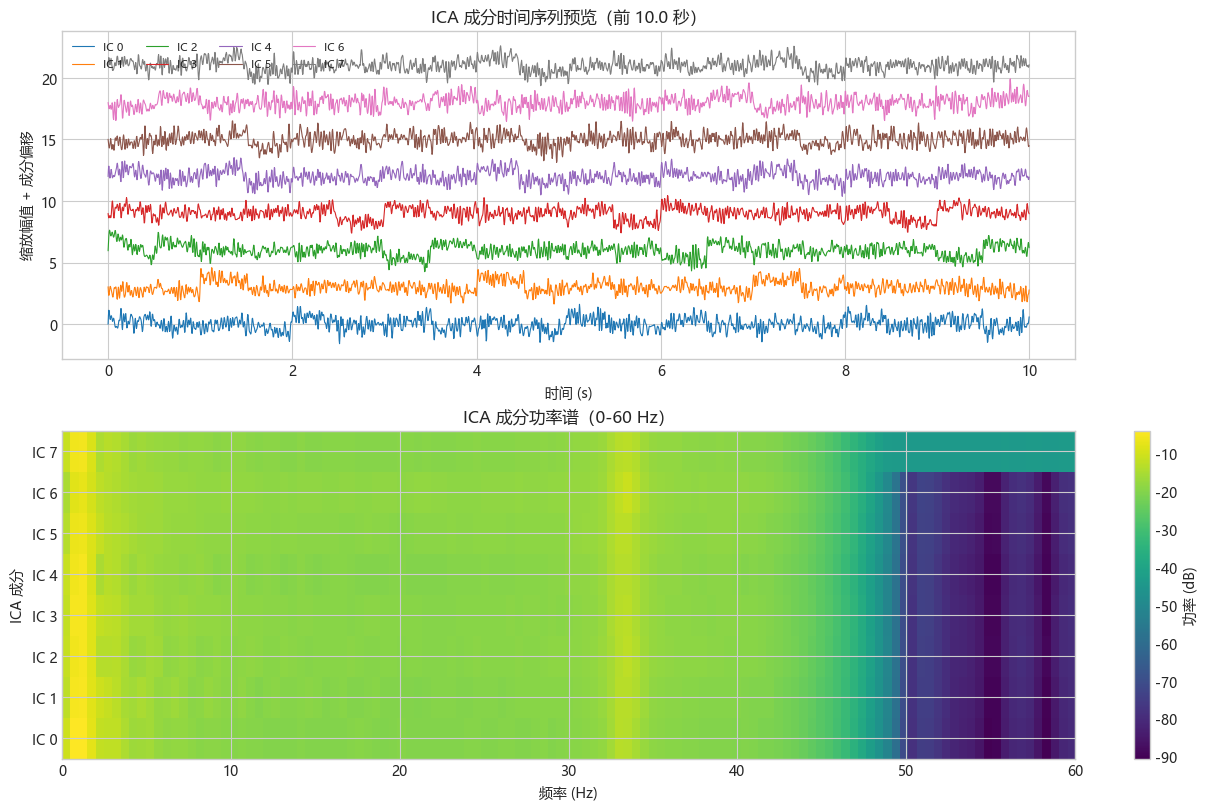

In [22]:
if ica is None:
    print("ICA 未拟合，跳过 ICA 可视化。")
else:
    sources = ica.get_sources(raw_clean).get_data()
    sfreq_ica = raw_clean.info["sfreq"]
    n_components, n_times = sources.shape

    preview_s = 10.0
    n_preview = min(int(round(preview_s * sfreq_ica)), n_times)
    t_preview = np.arange(n_preview) / sfreq_ica

    # 仅用于可视化：每个 ICA 成分去均值并按 95% 分位幅值缩放。
    source_preview = sources[:, :n_preview]
    source_centered = source_preview - source_preview.mean(axis=1, keepdims=True)
    source_scale = np.percentile(np.abs(source_centered), 95, axis=1, keepdims=True)
    source_scale = np.maximum(source_scale, 1e-12)
    source_for_plot = source_centered / source_scale
    offsets = np.arange(n_components) * 3.0

    fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

    for comp in range(n_components):
        axes[0].plot(t_preview, source_for_plot[comp] + offsets[comp], lw=0.8, label=f"IC {comp}")
    axes[0].set_title(f"ICA 成分时间序列预览（前 {n_preview / sfreq_ica:.1f} 秒）")
    axes[0].set_xlabel("时间 (s)")
    axes[0].set_ylabel("缩放幅值 + 成分偏移")
    axes[0].legend(ncol=4, fontsize=8)

    nperseg = min(int(round(2 * sfreq_ica)), n_times)
    freqs, psd = signal.welch(sources, fs=sfreq_ica, nperseg=nperseg, axis=1)
    freq_mask = freqs <= 60
    psd_db = 10 * np.log10(psd[:, freq_mask] + 1e-20)

    image = axes[1].imshow(
        psd_db,
        aspect="auto",
        origin="lower",
        extent=[freqs[freq_mask][0], freqs[freq_mask][-1], -0.5, n_components - 0.5],
        cmap="viridis",
    )
    axes[1].set_title("ICA 成分功率谱（0-60 Hz）")
    axes[1].set_xlabel("频率 (Hz)")
    axes[1].set_ylabel("ICA 成分")
    axes[1].set_yticks(np.arange(n_components))
    axes[1].set_yticklabels([f"IC {i}" for i in range(n_components)])
    fig.colorbar(image, ax=axes[1], label="功率 (dB)")

    print(f"ICA 成分数: {n_components}")
    print("检查建议：眨眼常表现为大幅低频瞬态；肌电常表现为较强高频功率；工频伪迹常在 50 Hz 附近突出。")

# 如果已经设置 montage 或通道位置信息，可以尝试取消注释下面的 topomap 图：
# if ica is not None:
#     ica.plot_components(inst=raw_clean)

## 8. 事件时间对齐和 trails 切分

CSV 中事件时间是 `epoch_ms`。EDF 中如果包含 `meas_date`，可以将事件时间转换成相对 EDF 开始的秒数：

`事件相对秒 = (事件 epoch_ms - EDF 开始 epoch_ms) / 1000`

切分时统一输出固定长度，默认每个 trail 取 5 秒。

In [24]:
def raw_start_epoch_ms(raw: mne.io.BaseRaw) -> float:
    meas_date = raw.info.get("meas_date")
    if meas_date is None:
        raise ValueError("EDF 缺少 meas_date，无法自动和 CSV 的 epoch_ms 对齐。")
    return meas_date.timestamp() * 1000.0


def choose_raw_start_epoch_ms(raw: mne.io.BaseRaw, trial_table: pd.DataFrame, n_samples: int) -> float:
    """选择能让最多事件落入 EDF 范围内的记录开始时间。

    有些 EDF 文件的开始时间会被 MNE 按 UTC 解释，而实验 CSV 的 epoch_ms 来自本地系统时间。
    因此这里额外尝试正负 8 小时修正，并选择可切分试次数最多的候选。
    """
    sfreq = raw.info["sfreq"]
    base_ms = raw_start_epoch_ms(raw)
    candidates = [base_ms, base_ms - 8 * 3600 * 1000, base_ms + 8 * 3600 * 1000]

    scores = []
    for candidate in candidates:
        valid = 0
        for _, row in trial_table.iterrows():
            onset_s = (float(row["start_epoch_ms"]) - candidate) / 1000.0
            start_idx = int(round(onset_s * sfreq))
            stop_idx = start_idx + n_samples
            valid += int(start_idx >= 0 and stop_idx <= raw.n_times)
        scores.append(valid)

    best_idx = int(np.argmax(scores))
    best = candidates[best_idx]
    correction_hours = (best - base_ms) / (3600 * 1000)
    # if correction_hours != 0:
    #     print(f"检测到 EDF/CSV 时间存在约 {correction_hours:+.0f} 小时偏差，已自动修正。")
    print(f"时间对齐候选可切分试次数: {scores}，使用第 {best_idx + 1} 个候选。")
    return best


def epoch_trials_from_raw(
    raw: mne.io.BaseRaw,
    trial_table: pd.DataFrame,
    trial_duration_s: float = 5.0,
) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    sfreq = raw.info["sfreq"]
    n_samples = int(round(trial_duration_s * sfreq))
    start_ms = choose_raw_start_epoch_ms(raw, trial_table, n_samples)

    data = raw.get_data()
    trials = []
    labels = []
    kept_rows = []
    skipped = []

    for _, row in trial_table.iterrows():
        onset_s = (float(row["start_epoch_ms"]) - start_ms) / 1000.0
        start_idx = int(round(onset_s * sfreq))
        stop_idx = start_idx + n_samples

        if start_idx < 0 or stop_idx > data.shape[1]:
            skipped.append((int(row["trial"]), row["target"], onset_s, start_idx, stop_idx))
            continue

        trials.append(data[:, start_idx:stop_idx])
        labels.append(row["label"])
        kept_rows.append(row)

    if skipped:
        print(f"跳过 {len(skipped)} 个越界试次。前 5 个:")
        for item in skipped[:5]:
            print(f"- trial={item[0]}, target={item[1]}, onset_s={item[2]:.3f}, sample=({item[3]}, {item[4]})")

    if not trials:
        raise RuntimeError("没有成功切分出任何试次，请检查 EDF meas_date 与事件 CSV 时间是否一致。")

    return np.stack(trials), np.asarray(labels), pd.DataFrame(kept_rows).reset_index(drop=True)


X0, y0, kept0 = epoch_trials_from_raw(raw_clean, trial_table0, trial_duration_s=5.0)
print(f"第一个 session 切分结果: X={X0.shape}, y={y0.shape}")
print("标签数量:")
for label, count in zip(*np.unique(y0, return_counts=True)):
    print(f"- {label}: {count}")

时间对齐候选可切分试次数: [0, 60, 0]，使用第 2 个候选。
第一个 session 切分结果: X=(60, 8, 1250), y=(60,)
标签数量:
- L: 20
- R: 20
- S: 20


## 9. 对所有 session 执行连续预处理并切分

下面会对每个 session 重复同样的连续预处理流程，然后再切分。ICA 默认只拟合、不剔除；如果你已经人工确认每个 session 的坏成分，可以在 `ICA_EXCLUDE_BY_SESSION` 中按 session 名填写。

In [25]:
ICA_EXCLUDE_BY_SESSION = {
    # 示例："go2_keyboard_sub01_session01": [0],
}

all_trials = []
all_labels = []
all_meta = []

for item in sessions:
    session_name = item["session_dir"].name
    print()
    print(f"处理 {session_name}")

    raw_session, ica_session = preprocess_continuous_raw(
        item["edf_path"],
        l_freq=1.0,
        h_freq=40.0,
        notch_freq=50.0,
        target_sfreq=250.0,
        bad_channels=None,
        run_ica=True,
        ica_exclude=ICA_EXCLUDE_BY_SESSION.get(session_name, []),
    )

    table = parse_trial_events(item["event_path"])
    X_session, y_session, kept = epoch_trials_from_raw(raw_session, table, trial_duration_s=5.0)
    kept["session_dir"] = session_name

    print(f"- 切分试次: {X_session.shape[0]}")
    all_trials.append(X_session)
    all_labels.append(y_session)
    all_meta.append(kept)

X = np.concatenate(all_trials, axis=0)
y = np.concatenate(all_labels, axis=0)
meta = pd.concat(all_meta, ignore_index=True)

print()
print("合并后数据")
print(f"- X: {X.shape}")
print(f"- y: {y.shape}")
print("标签数量:")
for label, count in zip(*np.unique(y, return_counts=True)):
    print(f"- {label}: {count}")



处理 go2_keyboard_sub01_session01
已拟合 ICA，但未自动剔除成分。请先人工检查成分后再设置 ica_exclude。
时间对齐候选可切分试次数: [0, 60, 0]，使用第 2 个候选。
- 切分试次: 60

处理 go2_keyboard_sub01_session02


c:\Users\zxzhang\Software\Anaconda3\envs\py310\lib\site-packages\sklearn\decomposition\_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


已拟合 ICA，但未自动剔除成分。请先人工检查成分后再设置 ica_exclude。
时间对齐候选可切分试次数: [0, 60, 0]，使用第 2 个候选。
- 切分试次: 60

处理 go2_keyboard_sub01_session03


c:\Users\zxzhang\Software\Anaconda3\envs\py310\lib\site-packages\sklearn\decomposition\_fastica.py:128: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


已拟合 ICA，但未自动剔除成分。请先人工检查成分后再设置 ica_exclude。
时间对齐候选可切分试次数: [0, 60, 0]，使用第 2 个候选。
- 切分试次: 60

合并后数据
- X: (180, 8, 1250)
- y: (180,)
标签数量:
- L: 60
- R: 60
- S: 60


## 10. 切分后的质量检查和基线校正

连续滤波和 ICA 已经在切分前完成。切分后仍然可以做试次级质量检查，例如剔除 peak-to-peak 幅值异常的试次，并减去每个试次前 0.5 秒的基线。

In [10]:
finite_mask = np.isfinite(X).all(axis=(1, 2))
trial_ptp = np.ptp(X, axis=2).max(axis=1)
median_ptp = np.median(trial_ptp)
mad_ptp = np.median(np.abs(trial_ptp - median_ptp))
robust_z = 0.6745 * (trial_ptp - median_ptp) / (mad_ptp + 1e-12)
artifact_mask = np.abs(robust_z) < 5
keep_mask = finite_mask & artifact_mask

print("试次级质量检查")
print(f"- 有效数值试次: {finite_mask.sum()} / {len(finite_mask)}")
print(f"- 保留试次: {keep_mask.sum()} / {len(keep_mask)}")
print(f"- 剔除试次: {(~keep_mask).sum()}")

sfreq = 250
baseline_samples = int(round(0.5 * sfreq))
X_kept = X[keep_mask]
y_kept = y[keep_mask]
meta_kept = meta.loc[keep_mask].reset_index(drop=True)

baseline = X_kept[:, :, :baseline_samples].mean(axis=2, keepdims=True)
X_baseline = X_kept - baseline

print(f"基线校正后: {X_baseline.shape}")


试次级质量检查
- 有效数值试次: 180 / 180
- 保留试次: 180 / 180
- 剔除试次: 0
基线校正后: (180, 8, 1250)


## 11. 可视化切分后的试次

这里画一个试次的所有通道。为了看清波形，只在图上做去均值和稳健缩放，不改变 `X_baseline`。

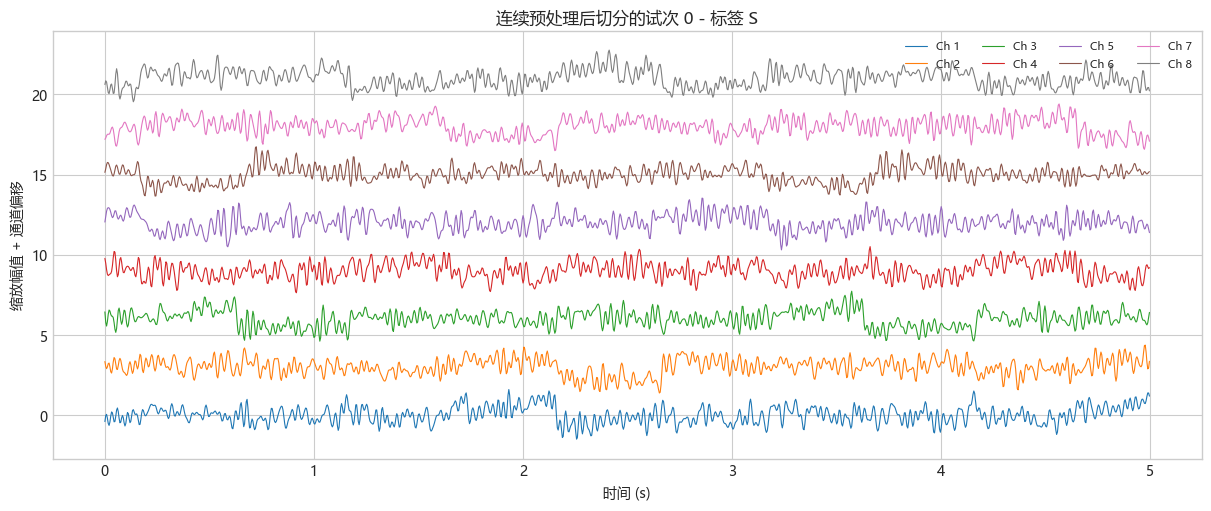

In [11]:
trial_idx = 0
trial_signal = X_baseline[trial_idx]
trial_centered = trial_signal - trial_signal.mean(axis=1, keepdims=True)
scale = np.percentile(np.abs(trial_centered), 95, axis=1, keepdims=True)
scale = np.maximum(scale, 1e-12)
trial_for_plot = trial_centered / scale

time = np.arange(X_baseline.shape[-1]) / sfreq
offsets = np.arange(X_baseline.shape[1]) * 3.0

fig, ax = plt.subplots(figsize=(12, 5), constrained_layout=True)
for ch in range(X_baseline.shape[1]):
    ax.plot(time, trial_for_plot[ch] + offsets[ch], lw=0.8, label=f"Ch {ch + 1}")
ax.set_title(f"连续预处理后切分的试次 {trial_idx} - 标签 {y_kept[trial_idx]}")
ax.set_xlabel("时间 (s)")
ax.set_ylabel("缩放幅值 + 通道偏移")
ax.legend(ncol=4, fontsize=8)
plt.show()


## 12. 标签编码并保存数据

保存的 `.npz` 是从原始连续 EDF 出发、先预处理后切分得到的数据。

In [26]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_kept)

np.savez_compressed(
    OUTPUT_PATH,
    eeg_feature=X_baseline.astype(np.float32),
    label=y_kept,
    label_encoded=y_encoded.astype(np.int64),
    label_classes=label_encoder.classes_,
    sfreq=sfreq,
    preprocessing="continuous_filter_reference_ica_then_epoch",
    keep_mask=keep_mask,
    session=np.asarray(meta_kept["session_dir"].astype(str)),
    trial=np.asarray(meta_kept["trial"].astype(int)),
    target=np.asarray(meta_kept["target"].astype(str)),
)

print(f"已保存: {OUTPUT_PATH}")
print(f"eeg_feature: {X_baseline.shape}")
print("标签编码:")
for cls, code in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"- {cls}: {code}")


已保存: C:\Users\zxzhang\Desktop\智能脑机接口\实验\data\go2_eeg_dataset_preprocessed_from_raw.npz
eeg_feature: (180, 8, 1250)
标签编码:
- L: 0
- R: 1
- S: 2
